# 第59篇：特征重要性与模型可解释性（SHAP）

> 这是「数据分析从入门到精通」系列的第 59 篇。LightGBM 学完了，这篇来解决机器学习的"最后一公里"——模型可解释性。模型预测出结果，业务方要问"为什么"，SHAP 就是最好的答案工具，让黑盒变透明。

---

## 一、为什么模型可解释性这么重要？

### 1.1 黑盒模型的困境

所谓黑盒（Black-Box），是指深度神经网络或高阶不确定模型中那成千上万个非线性交叉的参数。我们给它输入，它吐出极为精准的预测结果，但中间的决策过程，就像一个谁也看不透的深渊。

咱们辛辛苦苦训练了一个准确率95%的模型，结果业务方问："为啥这个客户会被预测为高风险？" 

你总不能回答："因为神经网络说他是高风险"吧？😅

这种“知其然而不知其所以然”的状态，带来了三个致命的系统性困境：
1. “哈士奇变狼”的偏见陷阱（信赖危机）
   一个经典的心理学与 AI 实验中，科学家训练了一个高精度模型来区分“哈士奇”和“狼”。结果模型几乎百发百中，但在面对一只背景是雪地的哈士奇时，模型决绝地把它判定成了狼。
通过可解释性工具（如 LIME 或 SHAP）拆解后才发现：模型根本没有去学习动物的瞳孔或毛发，它仅仅是学习了**“背景里有没有雪地”**（因为训练集里所有的狼都在雪地里）。

启示：如果没有可解释性，高准确率极有可能只是一场由“数据泄露”或“错误关联”编织的虚假繁荣。

2. 无法容纳“残差”的应力坍塌（安全危机）
   在金融风控、医疗诊断或自动驾驶等高风险领域，黑盒模型是一个“单点脆弱性”极高的系统。
    - 一个被异化了的医疗 AI，可能会因为检测仪器的一点点微小噪音（残差），而把一个良性肿瘤判定为恶性。
    - 医生如果不知道模型是根据哪一条病理特征得出的结论，就绝对不敢签字手术。因为黑盒模型一旦在边界上发生硬着陆，由于它“不解释、不容纳偏差、不听任何人反驳”，其带来的系统坍塌代价是百分之百的毁灭。

3. “无法迭代”的死锁状态（工程危机）
   作为技术开发人员，当你面对一个准确率突然下降的黑盒模型时，如果你不知道它内部的特征向量是如何正交、如何揉碎的，你就无法对它进行“精准的外科手术”。你唯一的办法就是盲目地增加入参、盲目地调整超参数。这种“盲盒式调优”会让工程开发陷入长期的停滞与死锁。

### 1.2 特征重要性的虚假安全感

有人会反驳：“谁说集成模型（如 XGBoost, LightGBM）是完全的黑盒？它们不是能直接打印出 feature_importances_（特征重要性）吗？”

这恰恰是数据分析人员最容易踩中的特征重要性陷阱。原生树模型的特征重要性，在很多时候带给你的只是一种“虚假的安全感”，它存在以下严重的局限性：

1. 它是全局的宏观妥协，抹杀了“微观个体”的独特性
原生特征重要性（基于 Split 或 Gain）告诉你：年收入在全校考生的贷款审批中重要性排第一。
但它无法回答：“为什么坐在我面前的这个具体的客户（张三），收入明明很高，却被模型无情拒绝了？”
特征重要性将数据彻底降维成了一个宏观的、一刀切的综合指标，它把个体在次要特征上的挣扎（比如张三虽然收入高，但最近一个月有多次高风险借贷记录）当成了噪音抹杀掉了。

2. 它分不清“因果”与“相关”，容易被“单点依赖”绑架
如果两个特征具有极高的线性相关性（比如用户的浏览时长和用户的点击次数）。在树模型分裂时，LightGBM 的 Leaf-wise 策略是一个绝对的结果导向制，它发现浏览时长稍微好用一点，就会揪住它疯狂往下长。
最终打印出的结果：浏览时长重要性 99%，点击次数重要性 1%。
但这并不意味着点击次数真的不重要。这种“单点单特征依附”的幻觉，会让分析人员做出极其偏颇的业务判断。

###  模型可解释性的重要性
- **调试与优化 (Debugging)**：帮开发人员看清骨架，明白怎么“修剪错题”
- **信任与合规 (Trust)**：金融、医疗等领域需要解释影响预测的关键因素和模型决策，帮业务方和监管层确信模型没有偏见，敢于签字授权
- **知识发现 (Discovery)**：帮业务人员从复杂的非线性组合中，反向挖掘出未知规律

做模型的减法和降维，是为了更好地看清世界的本质；而做模型的可解释性，是为了让我们在走向低维的结论时，永远不会迷失在高维的迷雾之中。

---

## 二、传统特征重要性方法

**2.1 基于树模型的特征重要性**

**2.1.1 底层的两大核心流派：基尼重要性（Gini Importance） 和 置换重要性（Permutation Importance）**

在数据挖掘和机器学习中，集成树模型（如 Random Forest、XGBoost、LightGBM）之所以成为工业界的常青树，不仅因为它们精准度高，还因为它们自带了一套“特征重要性（Feature Importance）”评估机制。这让原本偏向黑盒的集成算法，有了一张透视内部决策的“成绩单”。

**2.1.2 树模型（XGBoost 和 LightGBM）评估特征的三个核心维度**
1. 增益（Gain / Total Gain）—— 业务流的“吸金王”
   这是树模型中最经典、最主流的传统重要性评估方法。在分类任务中它基于 Gini（基尼不纯度），在回归任务中它基于 MSE（均方误差）。
   - 通俗解释：这个特征在所有的树里面，一共帮模型纠正了多少错题（降低了多少损失/误差）。
   - 应用场景：这是衡量特征对模型预测结果贡献度最客观、最核心的指标。 如果你想知道哪个特征对大盘的GMV、留存率影响最大，看 Gain 就对了。
   - 基尼重要性（Gini Importance）
       - 基尼重要性通常又被称为 平均不纯度减少（Mean Decrease Impurity, MDI）。它是随机森林（Random Forest）等传统树模型默认的特征评估指标。
       - 用于分类任务。
       - 训练模型时顺便算出来的，速度极快（免费送）。
       - 基尼重要性有一个臭名昭著的数学缺陷：它极其偏袒“高基数特征（High-cardinality features）”。如果你把一个完全随机的噪声列（比如一串随机数ID）放进模型，基尼重要性往往会把它评为“全场最重要特征”，但这纯粹是模型在死记硬背（严重过拟合）。
  - MSE（Mean Squared Error，均方误差）
       - 无论你在用线性回归、随机森林（Regressor），还是在训练一个庞大的神经网络，MSE 都在幕后扮演着冷酷的“终审法官”。
       - 用于预测连续的数值（如：房价、股票价格、销量）等回归任务。
       - 因为带有平方号，MSE 对大误差的惩罚是呈指数级爆发的。
2. 覆盖度（Cover / Total Cover）—— 普适性的“大管家”
   - 通俗解释：这个特征在分裂时，到底影响了多少个样本（打过交道的数据量）。
   - 应用场景：用来评估特征的普适性。一个特征可能增益很高，但如果它只对极少数（比如0.1%）的VIP用户生效，它的 Cover 就会很低。高 Cover 意味着这个特征在全局规则中具有广泛的代表性。
3. 频次（Weight / Split / Frequency）—— 刷脸的“劳模”
   - 通俗解释：这个特征在所有的树里，一共被拿来当了多少次“切分判据”（被切了多少刀）。
   - 应用场景：非常直观，但在实际工程中要极其警惕（下方会详细拆解它的陷阱）。它通常只能反映特征的活跃程度，并不直接代表它有多重要。

**2.1.3 指标对齐**
为了让你在切换不同的库时彻底不迷糊，我们把传统树模型、XGBoost 和 LightGBM 的特征重要性底层指标做一次大融合对齐：

| 核心内涵 | 单棵决策树、随机森林 (Scikit-Learn) | XGBoost 接口 | LightGBM 接口 |
| --- | --- | --- | --- |
| **看总共降低了多少误差** | `feature_importances_`<br><br>(基于 **Gini** 或 **MSE** 的不纯度减少) | `importance_type='gain'` | `importance_type='gain'` |
| **看分裂时一共牵扯了多少样本** | *底层有（节点Samples数）*<br><br>*但未直接封装成全局重要性指标* | `importance_type='cover'` | *底层有*<br><br>*但在全局重要性中未直接暴露出 cover 选项* |
| **看特征一共被切了多少刀** | *底层有（节点特征计数）*<br><br>*但未直接封装成全局重要性指标* | `importance_type='weight'` | `importance_type='split'` |

**2.1.4 树模型特征重要性的原生陷阱**

在日常特征工程中，如果你直接调用 model.feature_importances_，默认输出的指标往往会让你掉进算法设计的陷阱里。
1. 频次（Weight）对“连续特征”的疯狂偏袒
   - 现象：如果你的特征里有一个连续的浮点数指标（比如用户的精确账户余额），还有一个类别特征（比如性别：男/女）。当你打印 Weight 时，你会发现账户余额的重要性呈现出几百倍的压倒性优势。
   - 原因：因为性别只有 0 和 1 两种可能，树模型切一刀就切干净了，以后再也不需要用到它；而账户余额是个连续值，LightGBM 的直方图算法会把它分成 256 个箱子，模型为了把错题修正得更精细，会反复、多次地在不同的箱子边界上切刀。
   - 避坑提示：绝对不要盲目用 Weight 来做业务决策！ 它高，可能只是因为它是连续值，导致它在模型里疯狂“刷脸”，不代表它真的比只能切一刀的类别特征更有含金量。

2. 互斥与高相关特征的“功劳内卷”
   如果你的数据集里有两个高度相关的特征（例如：用户的手机话费余额 和 用户的手机充值总额）。
   - 在第一棵树分裂时，模型发现话费余额效果好了一点点，于是用了它。
   - 这一刀切下去之后，这两个特征共同包含的那部分“业务残差”就被消耗掉了。在后面的树里，充值总额能够发挥的空间被严重挤压。
   - 结果：最终报告里，话费余额重要性高达 80%，充值总额只有 5%。但如果你把话费余额拿掉，单独跑一遍，你会发现充值总额的重要性也会瞬间飙升到 80%。
   - 避坑提示：原生的特征重要性是非线性的、相互牵制的。不要看到一个特征得分低，就轻率地认为它在业务上毫无价值，它可能只是被它的“双胞胎兄弟”抢了风头。

下面我们跑一个由 Gini 驱动的随机森林---基于随机森林训练乳腺癌分类数据集，自动计算各特征对分类结果的贡献权重，按重要性从高到低输出排名前 10 的特征名称与对应分数，用于模型可解释性、特征筛选。

In [18]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_breast_cancer
import matplotlib.pyplot as plt
# 设置中文显示
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei','SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 加载数据
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target
feature_names = data.feature_names

# 训练随机森林
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

importance_df = pd.DataFrame(
    {"特征名称": feature_names, "基尼重要性 (Gini)": rf.feature_importances_}
).sort_values(by="基尼重要性 (Gini)", ascending=False)

print(importance_df.to_string(index=False))

                   特征名称  基尼重要性 (Gini)
             worst area      0.139357
   worst concave points      0.132225
    mean concave points      0.107046
           worst radius      0.082848
        worst perimeter      0.080850
         mean perimeter      0.067990
         mean concavity      0.066917
              mean area      0.060462
        worst concavity      0.037339
            mean radius      0.034843
             area error      0.029553
      worst compactness      0.019864
          worst texture      0.017485
           mean texture      0.015225
           radius error      0.014264
       worst smoothness      0.012232
       mean compactness      0.011597
        perimeter error      0.010085
         worst symmetry      0.008179
        mean smoothness      0.007958
fractal dimension error      0.005942
        concavity error      0.005820
      compactness error      0.005612
       smoothness error      0.004722
worst fractal dimension      0.004497
   concave p

如果面对的是预测连续数值的任务，把算法换成 MSE 驱动的回归森林

In [4]:
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# 1. 加载加州房价数据集（回归任务）
housing = fetch_california_housing()
X_reg = pd.DataFrame(housing.data, columns=housing.feature_names)
y_reg = housing.target  # 连续的房价数值

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# 2. 初始化随机森林回归器
# criterion='squared_error' 就是标准的 MSE（均方误差）
rf_mse = RandomForestRegressor(
    n_estimators=50, criterion="squared_error", max_depth=6, random_state=42
)

# 3. 训练模型
rf_mse.fit(X_train_r, y_train_r)

# 4. 提取并打印“MSE重要性”
print("\n 基于 MSE 的特征重要性排行榜:")
print("=" * 40)
importance_reg_df = pd.DataFrame(
    {"特征名称": X_reg.columns, "均方误差减少量 (MSE)": rf_mse.feature_importances_}
).sort_values(by="均方误差减少量 (MSE)", ascending=False)

print(importance_reg_df.to_string(index=False))


 基于 MSE 的特征重要性排行榜:
      特征名称  均方误差减少量 (MSE)
    MedInc       0.710768
  AveOccup       0.143873
  HouseAge       0.045922
  Latitude       0.038981
 Longitude       0.029218
  AveRooms       0.023041
Population       0.004886
 AveBedrms       0.003311



### 2.2 置换重要性（Permutation Importance）

置换重要性（Permutation Importance）不是任何一个算法专属的特产，它是“天下大同”的。它既不在 Random Forest 内部，也不在 XGBoost / LightGBM 内部，但你可以用它来评估它们中的任何一个。

如果用一句话来划清界限：基尼重要性/Gain重要性是**“模型自带的内部账本”；而置换重要性是“拿来审计任何模型的独立裁判”**。

它属于“体制外”，所以你不能通过 model.feature_importances_ 去打印它。你必须调用 Scikit-Learn 提供的独立审计工具 permutation_importance。

简而言之：
   - 为了打破基尼重要性这种“体制内”的偏见，科学家发明了置换重要性，它也被称为 平均准确率减少（Mean Decrease Accuracy, MDA）。
   - 它不仅能用于树模型，还能用于逻辑回归、SVM 甚至神经网络。
   - 抗过拟合能力强：由于它是在测试集/验证集上运行的，如果一个随机特征在训练集里靠死记硬背刷高了基尼重要性，当它到了测试集被随机打乱时，测试集的准确率根本不会有任何波动。因此，置换重要性能无情地戳穿那些虚高特征的谎言。
   - 但是它是模型训练完成后，额外进行洗牌测试，计算较慢。容易被高度相关的特征列蒙蔽，低估核心特征。

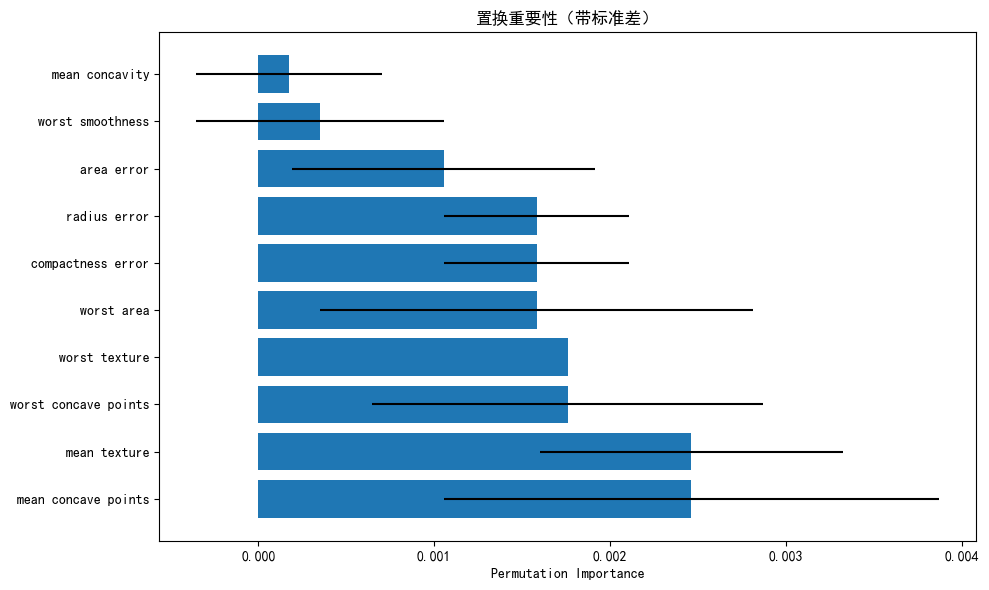

In [5]:
from sklearn.inspection import permutation_importance

# 计算置换重要性
perm_importance = permutation_importance(
    rf, X, y, 
    n_repeats=10, 
    random_state=42,
    scoring='accuracy'
)

# 可视化
import matplotlib.pyplot as plt

sorted_idx = perm_importance.importances_mean.argsort()[::-1][:10]
plt.figure(figsize=(10, 6))
plt.barh(range(10), perm_importance.importances_mean[sorted_idx], 
         xerr=perm_importance.importances_std[sorted_idx])
plt.yticks(range(10), [feature_names[i] for i in sorted_idx])
plt.xlabel('Permutation Importance')
plt.title('置换重要性（带标准差）')
plt.tight_layout()
plt.show()


**置换重要性的优势**：
- 不偏向高基数特征（如ID列）
- 适用于任何模型类型
- 能反映特征的真实预测能力

---

## 三、SHAP：统一的可解释性框架

**3.1 SHAP是什么？**

为了打破原生树模型特征重要性“分不清因果、偏袒连续值、无法解释个体”的困境，现代数据科学引入了基于合作博弈论的 SHAP（SHapley Additive exPlanations） 归因工具。

与原生特征重要性相比，SHAP 带来了降维打击式的优势：

- 它不仅懂“重不重要”，还懂“正反方向”：原生的 Gain 只能告诉你年龄很重要。而 SHAP 散点图能清晰地用颜色告诉你：年龄越大（红色），对预测结果是起到了拉动作用（正向），还是踩了刹车（负向）。

- 它能实现“微观个体”的精准确诊：原生的重要性是大盘的宏观妥协。而 SHAP 可以为某一个被拒绝贷款的特定客户（张三）单独生成一张瀑布图（Waterfall Plot），清晰指出：虽然张三的收入（PC1）很高，但他最近3个月的逾期次数，才是导致他最终被拒的致命一击。

在解释复杂模型（如 XGBoost、LightGBM、深度神经网络）时，SHAP 已经是目前工业界和学术界公认的 黄金标准（Gold Standard）。


**3.1.1 底层灵魂：来自诺贝尔奖的“分赃理论”**

SHAP 的数学底牌，来自诺贝尔经济学奖得主劳埃德·沙普利（Lloyd Shapley）提出的 **Shapley Value（沙普利值）**。它最初是用来解决“合伙人开公司，年底怎么公平分钱”的博弈问题。

**职场合伙人视角的通俗故事**

假设**张三、李四、王五**三个人合伙开了一家外卖店，年底一共净赚了 **100 万**。现在到了分红环节，如果只看谁打卡次数多、或者谁接单流水大，大家肯定要打架。

为了绝对公平，SHAP 引入了一个极其硬核的算法——**计算每个人的“边际贡献”**：

1. **单干**：算一下如果只有张三一个人开店，能赚多少？（比如 10 万）
2. **二人组**：算一下如果【张三 + 李四】一起干，能赚多少？（比如 60 万）。这时候，李四加入带来的**边际增量**就是 $60 - 10 = 50$ 万。
3. **三人组**：算一下如果【张三 + 王五】先干，李四再加入，李四又贡献了多少？
4. **终极平均**：把所有可能的组队顺序（排列组合）全部穷举一遍，算出李四在各种队伍里的平均贡献。**这个平均值，就是李四应得的红利（Shapley 值）。**

> **模型对齐**：在机器学习里，**“合伙人”就是特征**（如年龄、收入、负债），**“赚到的100万”就是模型预测出的具体数值**（如小明的贷款额度、或者患病概率）。SHAP 的核心任务，就是算出每个特征在各种组合下，到底为这单预测立下了多少功劳。

**3.1.2 数学面具：加性解释模型**

SHAP 的计算结果非常直观，它把黑盒模型的预测拆解成了**基线值**和各个特征的**正负推力**：

$$\text{最终预测值} = \text{大盘基线值} + \text{特征A的SHAP值} + \text{特征B的SHAP值} + \dots$$

* **大盘基线值（Base Value）**：如果把所有特征都挡住，模型闭着眼睛瞎猜的平均值（例如：全网用户的平均授信额度是 **10,000元**）。
* **SHAP 值（功劳值）**：
* 如果为**正数**，说明这个特征在踩**油门**（把预测值往高了推）。
* 如果为**负数**，说明这个特征在踩**刹车**（把预测值往低了拉）。

**3.1.3 降维打击：看懂 SHAP 的两张王牌可视化图**

传统特征重要性最让人痛苦的地方在于：它只告诉你“年龄很重要”，但无法告诉你“到底是年龄大重要，还是年龄小重要”。SHAP 用两张图彻底解决了这个问题。

- 王牌一：力导向图（Force Plot）—— 单个样本的精准诊断

这是拿去向非技术大老板或者监管机构汇报的“终极杀器”。它可以对某一个具体的人（比如客户小明）进行精准拆解：

* **中间的红蓝交界点**就是最终模型给小明算出的得分。
* **红色的箭头（油门）**：代表小明的`年龄=50`、`收入高`等特征，拼命在把小明的得分往右（高分）推。
* **蓝色的箭头（刹车）**：代表小明`近期有逾期记录`，伸出一只大脚拼命把得分往左（低分）拉。
* 一拉一推之间，最终停在哪，哪就是小明的专属于预测结果。因果关系，一目了然！

- 王牌二：摘要散点图（Summary Plot）—— 全局大盘的上帝视角

它把成千上万个样本的微观推力聚合在一起，形成了一张宏观的动态大盘图：

* **看行排序**：越往上的特征越重要。
* **看点颜色**：**红色**代表该特征自身数值高（如高收入），**蓝色**代表该特征自身数值低（如低收入）。
* **看左右位置（横轴）**：右边代表正向贡献（推高预测），左边代表负向贡献（拉低预测）。
* **秒读业务结论**：如果你看到某一行（比如`负债额`），**红色的点全部扎堆在右边，蓝色的点全部扎堆在左边**。这用大白话解释就是：负债额越高（红色），越会剧烈推高（右边）用户的违约风险。

**3.1.4 终极总结：为什么大家都爱 SHAP？**

| 评估维度 | 传统特征重要性 (如 Gain / Gini) | SHAP (沙普利加性解释) |
| --- | --- | --- |
| **解释粒度** | **宏观妥协**。只能看大盘整体，无法回答“为什么拒绝张三的贷款”。 | **宏观 + 微观**。既能看大盘，又能精准确诊每一个独立个案。 |
| **方向与因果** | **无**。只告诉你重要，不告诉你它是起到了促进作用还是抑制作用。 | **有**。清晰区分正负向贡献，甚至能捕捉特征之间的非线性转折点。 |
| **计算速度** | **极快**。模型训练完顺便就出来了（毫秒级）。 | **极慢**。因为要穷举排列组合，原生计算复杂度呈指数级爆炸。 |

> 💡 **技术小贴士**：由于原生的 SHAP 算得实在太慢，工业界目前普遍采用专门针对树模型优化的 **`TreeSHAP` 算法**（内置于 XGBoost/LightGBM 中），它利用树的内部结构把计算耗时缩短了成千上万倍，才让这项诺贝尔奖级的理论真正走向了实时风控、推荐系统的生产线。

**3.2 SHAP基础用法**

SHAP 是目前最流行的模型解释工具，来看看怎么用。用之前请先安装好哈（pip install shap）。

我们还是用之前的breast_cancer数据，执行以下核心步骤（仔细看代码和注释！）：
1. 初始化 SHAP 解释器 ：`shap.TreeExplainer(rf)`
2. 计算全局/局部归因值: `explainer(X) `
3. 处理多维输出结构: `if len(...) == 3`
4. 验证数据结构

In [12]:
import shap

# ======== 1. 初始化 SHAP 解释器 =====
# 创建Explainer
explainer = shap.TreeExplainer(rf)  

# ======== 2. 计算全局/局部归因值=====
# explainer()计算全局/局部归因值，
# explainer(X) 对数据集 X 进行推理，计算出每个样本、每个特征对模型输出的边际贡献值（即 SHAP Values）
shap_values_object = explainer(X)   

# ======== 3. 处理多维输出结构=====
# SHAP 对象支持直接切片 [样本, 特征, 类别]
# 当模型是多分类任务时，SHAP 返回的形状通常是 (样本数, 特征数, 类别数)。
# 代码通过切片 [:, :, 1] 提取了第 2 个类别（索引为 1）的 SHAP 值
if len(shap_values_object.shape) == 3:
    shap_values_class1 = shap_values_object[:, :, 1]
else:
    # 某些低版本或特殊配置下如果已经是二维，则直接赋值
    shap_values_class1 = shap_values_object

# ======== 4. 验证数据结构=====
print(f"SHAP 归因对象形状: {shap_values_class1.shape}")
print(f"特征数: {len(feature_names)}")


SHAP 归因对象形状: (569, 30)
特征数: 30


**3.3 全局特征重要性**

在 SHAP 的模型可解释性分析中，Summary Plot（摘要图/蜂群图）和条形图（Bar Plot）是两种最核心的全局解释工具。它们虽然都用于评估特征的重要性，但在信息维度和应用场景上有显著的区别。

**3.3.1 Summary Plot（摘要图 / 蜂群图）**
这是信息量最丰富、最常用的全局可视化工具，它同时展示了特征的重要性、影响方向以及特征值与预测结果之间的关系。

**图表结构：**
- Y轴：特征名称，按全局重要性（SHAP绝对值的均值）从高到低排序。
- X轴：SHAP值。点越靠右（正值），表示该特征将预测结果推向正类（或推高预测值）；点越靠左（负值），表示将预测推向负类。
颜色：代表特征的原始取值大小。通常红色表示高值，蓝色表示低值。

**核心价值：**
- 影响方向：不仅能看出哪个特征重要，还能看出它是起正向作用还是负向作用。
- 特征值关联：通过颜色分布，可以直观观察特征值大小与预测结果的关系。例如，如果红色点集中在X轴右侧，说明该特征值越大，对预测的正向影响越强。
- 交互效应：如果某个特征的红点和蓝点在X轴上广泛混杂分布，说明该特征的影响严重依赖于其他特征的值（存在较强的交互效应）。

下面演示一下如何绘制Summary Plot（摘要图/蜂群图）。


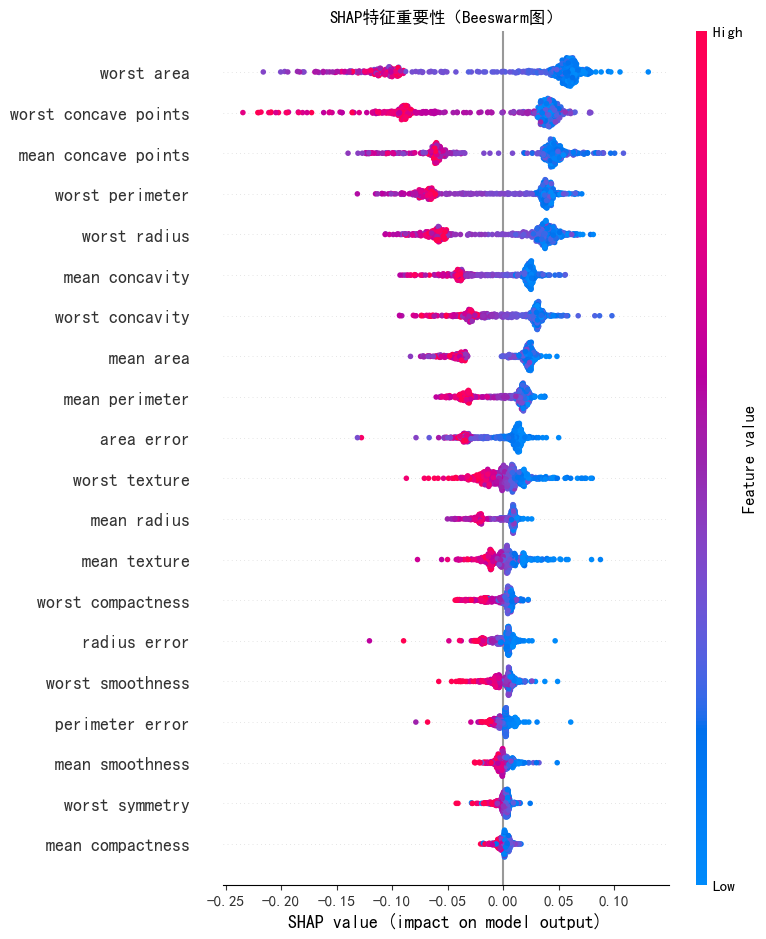

In [13]:
# 绘制SHAP summary plot（ beeswarm图）
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_class1, X, feature_names=feature_names, show=False)
plt.title('SHAP特征重要性（Beeswarm图）')
plt.tight_layout()
plt.show()


**Beeswarm图解读**：
- **纵轴**：特征按重要性排序
- **横轴**：SHAP值（正负表示影响方向）
- **颜色**：特征值大小（红=大，蓝=小）
- **分布**：每个点代表一个样本

**3.4 条形图版本（Bar Plot）**

这是摘要图的简化版，专注于纯粹的特征重要性排序。在代码中通常通过设置 plot_type="bar" 来生成。
**图表结构：**
- Y轴：特征名称，按重要性降序排列。
- X轴：特征的平均绝对 SHAP 值（mean(|SHAP value|)）。

**核心价值：**
- 忽略方向：通过取绝对值，条形图抹除了正负方向的差异，只关注特征对模型预测结果的“整体贡献大小”。
- 简洁直观：图表非常干净，没有散点和颜色的干扰，非常适合快速把握最重要的 Top N 特征。

下面演示如何绘制条形图。

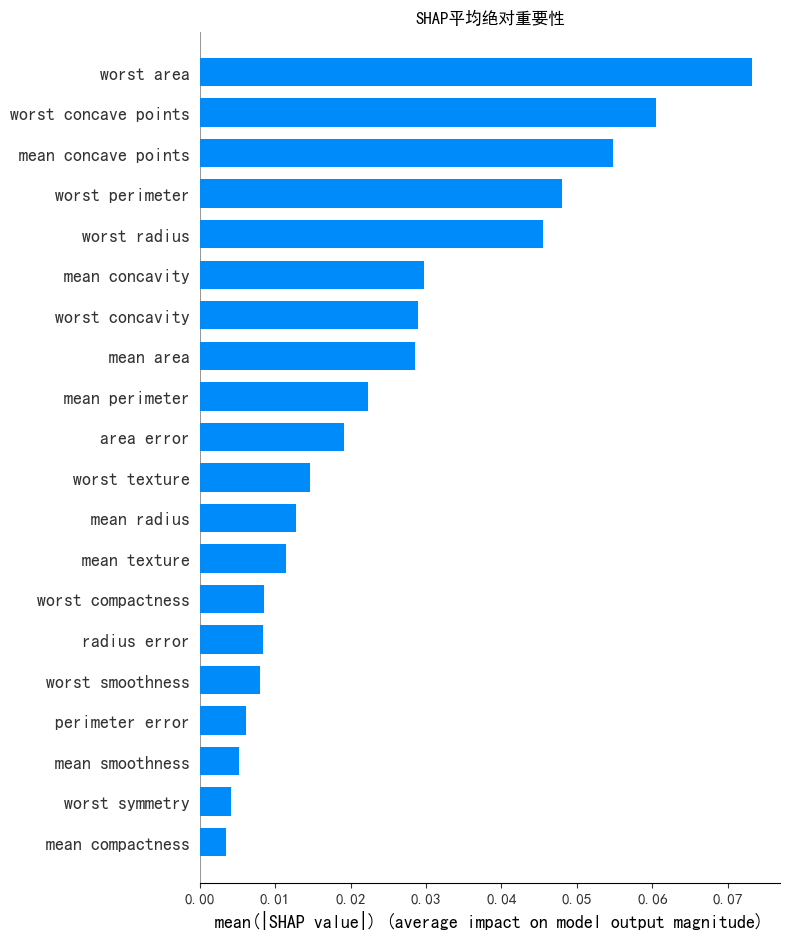

In [14]:
# 条形图版本（更简洁）
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_class1, X, feature_names=feature_names, 
                  plot_type="bar", show=False)
plt.title('SHAP平均绝对重要性')
plt.tight_layout()
plt.show()

**总结与业务应用建议：**
- 向业务方汇报时（使用条形图）：条形图更适合用于业务报告或文档中，因为它能直接、清晰地回答“影响客户流失/违约的最核心驱动因素是什么”，帮助业务团队将资源优先投入到改善这些核心特征上。
- 模型调试与深度分析时（使用 Summary Plot）：摘要图是模型调试的“第一眼”工具。它不仅能验证业务常识（例如：年龄越大，违约概率越高），还能帮助发现异常模式（如业务上认为重要的特征排名靠后，提示可能存在特征工程问题或共线性问题）。

---

## 四、个体预测解释

如果说 Summary Plot（摘要图）和 Bar Plot（条形图）是从“上帝视角”俯瞰整个数据集的全局特征重要性，那么 Waterfall Plot（瀑布图）和力图（Force Plot） 则是将镜头拉近，针对单个特定样本进行“微观解剖”的利器。

### 4.1 瀑布图：单个样本的解释

瀑布图将单个样本的预测过程拆解为一条可视化的“推理路径”：
- 起点（Base Value / E[f(x)]）：图表最左侧的起点是模型的基准值（通常是训练集中所有样本预测值的平均值，或正负样本的比例）。这代表了模型在没有任何特征信息时的“初始猜测”。
- 中间过程（特征贡献）：每一个特征都会产生一个正向（红色，推高预测）或负向（蓝色，拉低预测）的 SHAP 值。这些贡献值像瀑布一样，依次在前一个值的基础上进行累加或扣减。
- 终点（Model Output / f(x)）：图表最右侧的终点是所有特征贡献累加后的最终结果，即模型对该样本的实际预测值（或预测概率）。

以下代码演示如何生成瀑布图。

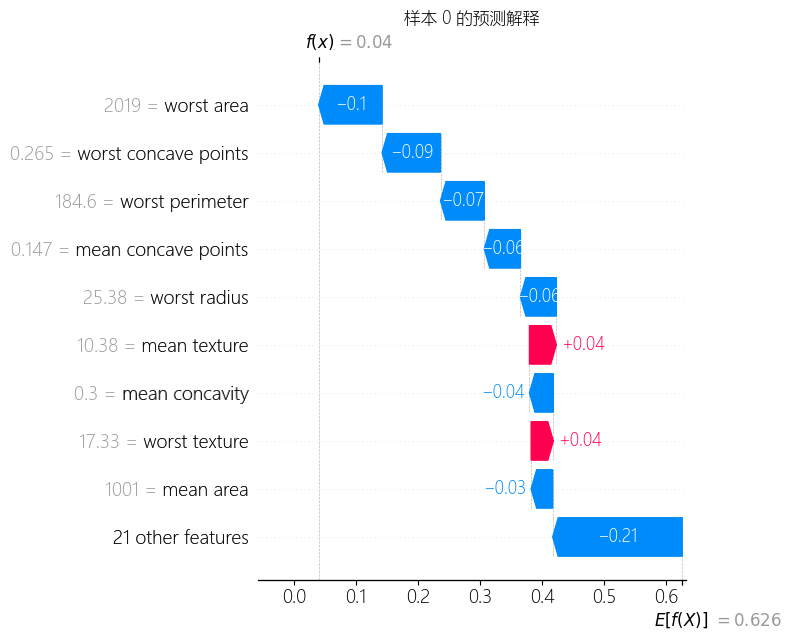

基础值（平均预测）: 0.6258
当前样本各个特征SHAP值之和: -0.5858
实际预测概率（Class 1）: 0.0400


In [24]:
# 选择第一个样本进行解释
sample_idx = 0

single_sample_shap = shap_values_class1[sample_idx]

# 创建瀑布图
plt.figure(figsize=(12, 8))
shap.plots.waterfall(single_sample_shap, max_display=10, show=False)

plt.title(f'样本 {sample_idx} 的预测解释')
plt.tight_layout()
plt.show()

print(f"基础值（平均预测）: {explainer.expected_value[1]:.4f}")
print(f"当前样本各个特征SHAP值之和: {single_sample_shap.values.sum():.4f}")
# 预测概率需要传入 DataFrame 的切片
prob = rf.predict_proba(X.iloc[sample_idx:sample_idx+1])[0][1]
print(f"实际预测概率（Class 1）: {prob:.4f}")

**瀑布图解读**：
- **E[f(X)]**：基础值（所有样本的平均预测）
- **红色箭头**：推动预测增高的特征
- **蓝色箭头**：推动预测降低的特征
- **f(x)**：最终预测值

### 4.2 力图（Force Plot）

如果说瀑布图（Waterfall Plot）是用严谨的“加减法”来展示模型的推理逻辑，那么 Force Plot（力图） 则是将这种逻辑转化为一种更具视觉冲击力的“物理拔河”隐喻。它是 SHAP 库中最具代表性、最直观的局部（Local）解释工具之一。

力图将单个样本的预测过程具象化为两股力量的对抗与平衡：
- 中心基准点（Base Value）：图表中间有一条基准线，代表模型的基准值（即训练集预测值的平均期望 E[f(x)]。
- 正向推力（红色箭头）：将预测结果推向正类（或推高预测值）的特征，以红色箭头表示。箭头越长，说明该特征的正向贡献越大。
- 负向拉力（蓝色箭头）：将预测结果推向负类（或拉低预测值）的特征，以蓝色箭头表示。箭头越长，说明该特征的负向贡献越大。
- 最终落点（Model Output）：所有红蓝箭头在基准线两侧相互拉扯后，最终达到的平衡位置，就是模型对该样本的最终预测值 f(x)。

下面演示绘制单个样本的力图。

<Figure size 1500x400 with 0 Axes>

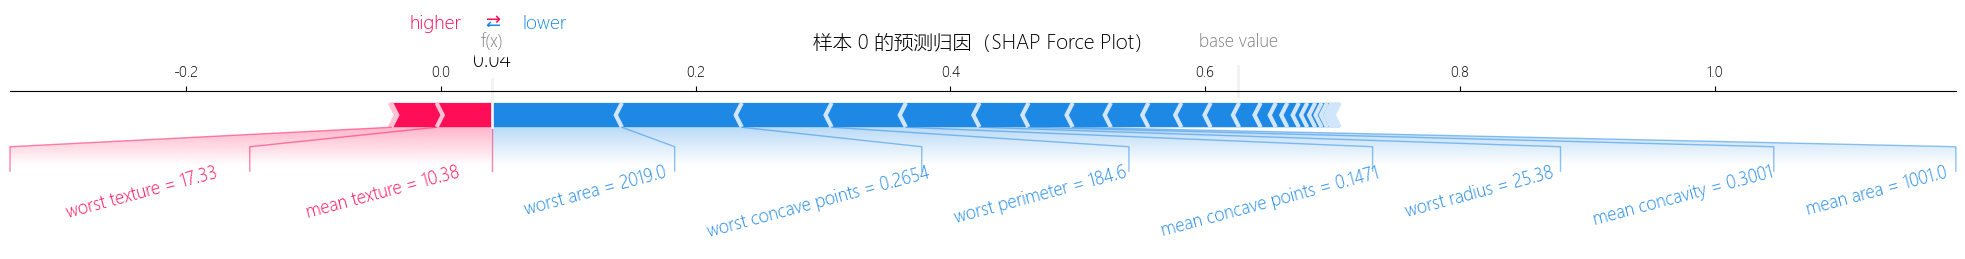

In [47]:
# 确保你已经运行了之前的代码，拥有 rf, X, explainer 以及 shap_values_class1

sample_idx = 0

# 1. 核心：从总的 SHAP 对象中切出第 0 个样本的正类解释对象
single_sample_shap = shap_values_class1[sample_idx]

# 2. 初始化 matplotlib 窗口（新版 SHAP 绘制单个 Force Plot 必须显式指定 matplotlib=True）
plt.figure(figsize=(15, 4))

# 3. 绘图
# matplotlib=True 会强制将其渲染为静态的 matplotlib 图表，适合保存和在主流 IDE 中显示
# text_rotation=15 可以让特征标签微微倾斜，防止重叠文字碎裂
shap.plots.force(
    single_sample_shap, 
    matplotlib=True, 
    text_rotation=15,
    show=False
)

plt.title(f'样本 {sample_idx} 的预测归因（SHAP Force Plot）', fontsize=14, pad=30)
plt.tight_layout()
plt.show()

这张 SHAP 力图（Force Plot）展示了一个特定样本（样本 0）的预测归因过程。它形象地解释了模型是如何从基准值出发，经过各个特征的“拉扯”，最终得出该样本的预测结果的。这是一个被判定为“低风险/低数值”的样本。

1. 最终结果（f(x)）：图表上方的刻度显示，最终预测值 f(x) 落在 0.04 附近。基准值（Base Value）：图表右侧显示的 base value 约为 0.63。这意味着该样本具有强烈的特征组合，使得模型认为其属于“负类”或“低数值”区间。
2. 红色箭头（推高预测值）：主要特征：worst texture = 17.33 和 mean texture = 10.38，将预测值往高了推（推向正类/高风险）
3. 蓝色箭头（拉低预测值）：主要特征：worst area = 2019.0、worst concave points = 0.2654、worst perimeter = 184.6 等，这些特征形成了强大的合力，将预测值猛烈地向左拉（推向负类/低风险）。

尽管它的纹理（texture）特征倾向于让它被归类为正类（红色部分），但它巨大的面积（area）、周长（perimeter）以及凹点数（concave points）产生了更强大的反向作用力（蓝色部分）。最终，蓝色的力量战胜了红色的力量，将预测结果从基准线 0.63 强行拉低到了 0.04。

### 4.3 多个样本的力图

如果说单个样本的力图（Force Plot）是聚焦于“单兵作战”的微观分析，那么多样本力图（Stacked Force Plot）则是将视角拉高，展示整个群体“排兵布阵”的宏观概览。
它通过将多个样本的力图进行垂直堆叠（旋转90度并排），形成了一张极具视觉冲击力的“战况全景图”。

还可以通过滑块或下拉菜单，按特定特征（如“年龄”或“收入”）对堆叠的力图进行重新排序，从而动态发现不同特征值下的群体决策规律。

多样本力图保留了单个力图中“基准值”与“红蓝力量对抗”的物理隐喻，但在群体层面上揭示了更深层的模式：
- 垂直堆叠：每一个垂直的条带代表一个样本的预测过程。
- 整体分布：通过观察密集排列的条带，可以直观地看出整个数据集中，正向特征（红色）和负向特征（蓝色）的整体占优情况。
- 异常识别：在整齐排列的条带中，如果某个样本的颜色或长度显得极为突兀，数据科学家可以迅速定位到这些“异常预测”或“极端样本”。


In [46]:
# 初始化JS前端依赖，为SHAP交互式可视化提供渲染环境
# 仅Jupyter Notebook/Lab需要，纯py脚本可注释掉此行
shap.initjs()
# 查看前50个样本的整体模式
shap.plots.force(
    shap_values_class1[:50]
)

图形解读：

- 整体趋势（蓝色主导）：图表中绝大部分区域被蓝色覆盖，且位于基准线下方。这意味着在所展示的这一批样本中，绝大多数样本的特征组合都在将预测值向下拉（降低预测概率或数值）。
- 基准线与最终值：左侧纵轴显示基准值约为 0.97（把鼠标悬停在横轴42），而大多数样本的最终预测值 f(x) 落在了 0.2258 到 0.6258 之间的较低区间。这表明该批次样本普遍具有抑制模型输出正类（或高数值）的特征属性。
- 在第 42 个样本附近，原本平稳的蓝色带状图突然向上剧烈突起，变成了大面积的红色。这表示该样本（或这一小簇样本）的预测值被强力推高，显著偏离了群体的平均水平。悬浮的标注明确指出了导致这一突变的元凶——worst area = 698.8、worst perimeter、worst concave points 等特征呈现红色。这说明当这些关键的形态学特征（面积、周长、凹点数）数值发生特定变化时（在此处可能是数值变大），它们会从原本的“抑制因素”瞬间转变为“促进因素”，导致模型对该样本的判定发生根本性逆转。这通常是模型捕捉到的强信号特征。
- 顶部的下拉菜单显示 sample order by similarity。这意味着样本并非随机排列，而是根据特征贡献的相似度进行了聚类。从第 0 个样本到第 40 个样本，红蓝力量的分布非常稳定，第 42 号样本处的剧烈变化，标志着数据分布的一个“断层”。在实际业务中，这可能代表了两个截然不同的客户群体、两种不同的病理状态，或者是数据集中混入的一小部分特殊样本。

---

## 五、特征交互与依赖图

### 5.1 依赖图（Dependence Plot）

依赖图（Dependence Plot）是 SHAP 可解释性分析中用于揭示“特征值与模型预测之间非线性关系”的核心工具。它超越了简单的线性相关性，能够展示模型是如何利用某个特征的特定取值区间来做出决策的，甚至能发现特征之间的交互效应。

依赖图的本质是一个增强版的散点图，它将每个样本在某个特征上的原始取值与其对应的 SHAP 值进行映射：
- X 轴（特征值）：表示该特征在数据集中的实际观测值。例如，如果特征是“年龄”，X 轴就是具体的岁数。
- Y 轴（SHAP 值）：表示该特征对模型预测结果的边际贡献。正值意味着推高预测结果（如增加违约概率），负值意味着拉低预测结果。
- 颜色编码（交互特征）：这是依赖图的精髓。默认情况下，点的颜色通常由与该特征交互作用最强的另一个特征决定（也可以通过参数手动指定）。颜色的渐变揭示了第三个变量是如何调节当前特征的影响效果的。

<Figure size 1000x600 with 0 Axes>

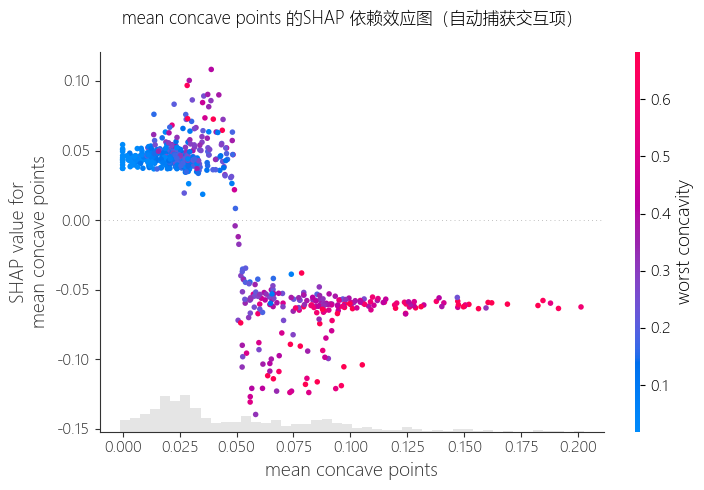

In [49]:
# 确保此时的 shap_values_class1 是通过 `explainer(X)[:, :, 1]` 拿到的 Explanation 对象
feature = 'mean concave points'

plt.figure(figsize=(10, 6))

# color 参数传入一个 SHAP 对象，它会自动计算并对产生最强交互作用的“幕后黑手特征”进行颜色编码（红蓝渐变）
shap.plots.scatter(
    shap_values_class1[:, feature], 
    color=shap_values_class1,
    show=False
)

plt.title(f'{feature} 的SHAP 依赖效应图（自动捕获交互项）', fontsize=12, pad=20)
plt.tight_layout()
plt.show()

这张图不仅展示了mean concave points（平均凹点数）与预测值的非线性关系，还通过颜色编码自动捕捉并展示了它与另一个特征worst concavity（最坏凹度）的交互效应。
1. 核心结论：存在明显的“阈值效应”
- X轴（特征值）：mean concave points 的取值范围大致在 0 到 0.2 之间。
- Y轴（SHAP值）：代表该特征对模型输出的贡献度。正值表示推高预测结果（例如增加恶性概率），负值表示拉低预测结果。
- 关键发现：图中呈现出一个非常清晰的阶梯状或断崖式分布。
   - 当 mean concave points < 0.05 时，SHAP 值几乎全部为正（约 +0.05）。这意味着只要这个数值很小，模型就会倾向于给出一个正向的基准贡献。
   - 当 mean concave points > 0.05 时，SHAP 值迅速下降变为负值（约 -0.05 到 -0.15）。这意味着一旦超过这个临界点，该特征就会开始抑制模型的预测输出。

2. 交互效应分析（颜色的含义）
- 蓝色区域（低 worst concavity）：
    - 主要集中在 X 轴左侧（< 0.05）以及 Y 轴较高的位置。
    - 这说明当样本的“最坏凹度”较低时，即使“平均凹点数”稍微波动，其对模型的正向贡献依然比较稳定且较高。
- 红色/紫色区域（高 worst concavity）：
    - 主要分布在 X 轴右侧（> 0.05）的下半部分。
    - 这揭示了一个有趣的交互现象：当 mean concave points 变大（超过阈值）时，如果同时伴随着较高的 worst concavity（红色点），SHAP 值往往会变得更低（更负）。
    - 业务解读：这表明模型认为，“平均凹点数大”本身就是一个负面信号（降低预测值），而如果此时“最坏凹度”也很大，这种负面影响会被进一步放大。

3. 数据分布直方图
   底部的灰色直方图展示了 mean concave points 在数据集中的分布情况。可以看出，大部分样本集中在 0.025 附近，属于低值区。只有少数样本落在 0.05 以上的高值区。这也解释了为什么左侧的点看起来更密集。

---

## 六、综合实战：解释银行客户流失模型

### 6.1 数据准备与建模

先把数据准备好，这是分析的第一步：


In [38]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
import warnings
# 💡 把这行放在代码最前面，屏蔽掉所有的未来警告
warnings.filterwarnings('ignore', category=FutureWarning)

# 创建模拟的银行客户数据
np.random.seed(42)
n_samples = 1000

data = pd.DataFrame({
    'age': np.random.randint(18, 80, n_samples),
    'tenure': np.random.randint(0, 20, n_samples),
    'balance': np.random.exponential(10000, n_samples),
    'num_products': np.random.randint(1, 5, n_samples),
    'has_credit_card': np.random.randint(0, 2, n_samples),
    'is_active': np.random.randint(0, 2, n_samples),
    'estimated_salary': np.random.normal(100000, 20000, n_samples),
    'complaints': np.random.poisson(1, n_samples)
})

# 创建目标变量（流失概率）
# 投诉多、不活跃、 tenure短的更容易流失
churn_prob = 1 / (1 + np.exp(-(
    -0.02 * data['age'] +
    -0.1 * data['tenure'] +
    0.3 * data['complaints'] +
    -0.5 * data['is_active'] +
    0.1 * (data['balance'] > 50000).astype(int) +
    np.random.normal(0, 0.5, n_samples)
)))
data['churned'] = (churn_prob > 0.5).astype(int)

# 划分数据
X = data.drop('churned', axis=1)
y = data['churned']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 训练XGBoost模型
model = XGBClassifier(n_estimators=100, max_depth=4, random_state=42)
model.fit(X_train, y_train)

print(f"训练集准确率: {model.score(X_train, y_train):.4f}")
print(f"测试集准确率: {model.score(X_test, y_test):.4f}")


训练集准确率: 1.0000
测试集准确率: 0.9850


### 6.2 SHAP解释

下面代码演示如何使用 SHAP 库生成全局特征重要性条形图（Bar Plot），以直观量化并展示银行客户流失模型中各个特征的核心驱动力。

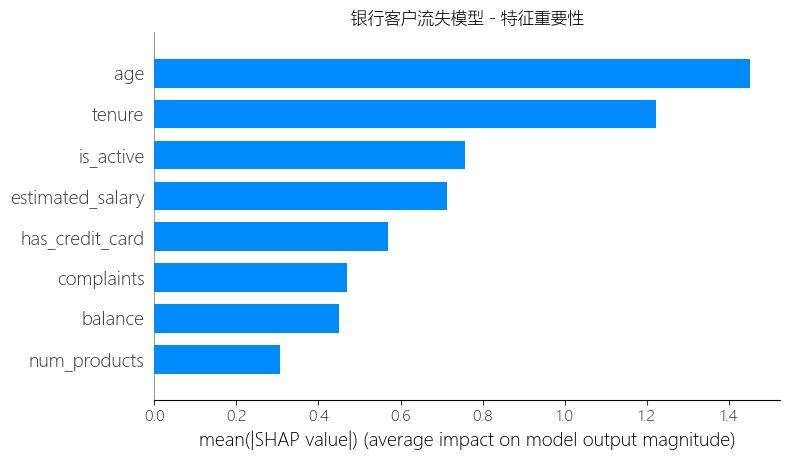

In [39]:
# 创建SHAP解释器
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# 全局特征重要性
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title('银行客户流失模型 - 特征重要性')
plt.tight_layout()
plt.show()


### 6.3 业务洞察报告

模型建好了，更重要的是把结果翻译成业务语言。

下面这段代码从模型预测结果中筛选出高风险客户，并利用 SHAP 值对每个高风险个案进行归因分析。它将“谁有风险”与“为什么有风险”这两个关键问题结合在了一起。

主要步骤（认真看代码和注释！）：
1. 风险筛选（定位目标）：`model.predict_proba(X_test)[:, 1] > 0.8`
2. 归因计算（寻找原因）：`shap_values[...]`,`dict(zip(...))`
3. 排序与输出（提炼重点）：`sorted(..., key=lambda x: abs(x[1]), reverse=True)`

In [40]:
# ==============1. 风险筛选（定位目标）===================
# 找出高风险客户并解释原因
high_risk_idx = X_test.index[model.predict_proba(X_test)[:, 1] > 0.8] # 只关注流失概率超过 80% 的极端样本

print("高风险客户分析示例：")
print("=" * 60)

for idx in high_risk_idx[:3]:
    print(f"\n客户ID: {idx}")
    print(f"流失概率: {model.predict_proba(X_test.loc[idx:idx])[:, 1][0]:.2%}")  
    print("关键影响因素：")

    # ==============2. 归因计算（寻找原因）===================
    # shap_values[...] 针对每一个被选中的高危客户，提取其对应的 SHAP 值向量
    # dict(zip(...))：将特征名称与对应的 SHAP 值一一对应，建立字典映射。
    shap_dict = dict(zip(X.columns, shap_values[X_test.index.get_loc(idx)]))
     # ==============排序与输出（提炼重点）===================
    sorted_shap = sorted(shap_dict.items(), key=lambda x: abs(x[1]), reverse=True)
    
    for feature, value in sorted_shap[:3]:
        direction = "增加" if value > 0 else "降低"
        print(f"  - {feature}: {direction}流失风险 (SHAP={value:.3f})")


🔍 高风险客户分析示例：

客户ID: 845
流失概率: 95.29%
关键影响因素：
  - tenure: 增加流失风险 (SHAP=3.825)
  - age: 增加流失风险 (SHAP=2.223)
  - has_credit_card: 增加流失风险 (SHAP=0.821)


---

## 七、SHAP进阶技巧

**7.1 不同模型的SHAP支持**

在实际的工程落地中，不同的机器学习模型，其背后的 SHAP 计算逻辑、速度以及调用的接口是完全不同的。

SHAP 库之所以强大，是因为它针对不同的底层算法模型，量身定制了不同的 “解释器（Explainer）”。如果选错了解释器，要么模型会报错拒绝执行，要么计算速度会慢到让人绝望（从几秒钟飙升到几天）。

In [ ]:
# 树模型（XGBoost, LightGBM, CatBoost, sklearn树模型）
explainer = shap.TreeExplainer(model)

# 线性模型
explainer = shap.LinearExplainer(model, X_train)
shap_values = explainer(X_test)

# 深度学习模型
# 需要传入模型和一部分背景数据（通常用训练集的子集）作为基准参考
explainer = shap.DeepExplainer(model, data=X_train_summary)
shap_values = explainer(X_test)

# 任意模型（基于采样的近似）
# 必须传入模型的预测函数（predict_proba 或 predict）
explainer = shap.KernelExplainer(model.predict_proba, X_train_summary)
# 实战中强烈建议对 X_test 进行切片，只测几个样本，否则电脑会卡死
shap_values = explainer(X_test.iloc[:10])

四种支持方式汇总对比：

| 解释器名称 (Explainer) | 适用模型范围 | 计算速度 | 实战致命陷阱与建议 |
| --- | --- | --- | --- |
| **`TreeExplainer`** | XGBoost, LightGBM, CatBoost, Sklearn 树 | **极快** (秒级) | **最优先推荐。** 表格数据、风控、推荐系统模型的绝对王牌。 |
| **`DeepExplainer`** | PyTorch, TensorFlow / Keras | **中等** | 输入数据需要保持与网络输入 Tensor 形状、类型完全一致。 |
| **`LinearExplainer`** | Linear / Logistic Regression, Lasso | **瞬时** (毫秒级) | 当特征之间存在极度严重的共线性时，算出来的 SHAP 值可能不够稳定。 |
| **`KernelExplainer`** | SVM, KNN, 以及任何无法归类的黑盒模型 | **极慢** (乌龟级) | **逼不得已才用。** 必须用 `shap.kmeans` 或采样对背景数据集进行强力瘦身，否则会直接算到死机。 |

**现在的现代化快捷入口：**`shap.Explainer`

可能 SHAP 的作者也觉得让用户自己挑这四个 Explainer 太麻烦了，于是在较新的版本里提供了一个**智能托管工厂**：**`shap.Explainer(model, ...)`**。

你把 `model` 扔给它，它会在底层自动嗅探模型的基因：如果是 LightGBM 就自动在后台无缝切成 `TreeExplainer`；如果是 PyTorch 就自动切成 `DeepExplainer`；如果啥都不是，就默默启动 `KernelExplainer` 帮你硬啃。

**7.2 SHAP值与特征工程**

SHAP 真正的降维打击能力，在于反哺“特征工程（Feature Engineering）”。 传统特征工程全靠“猜”和“经验试错”，而有了 SHAP，特征工程就有了高清 X 光机。它能帮你完成从特征筛选、特征交叉、连续值分箱到脏数据清洗的全链路闭环。

以下代码展示如何利用 SHAP 归因结果进行数据驱动的特征筛选。它将模型内部的解释性数据转化为结构化的特征重要性排序，并从中提取出对预测最具影响力的核心特征。主要步骤：
1. 计算全局特征重要性：`np.abs(shap_values).mean(axis=0)`
2. 构建结构化特征重要性表：将计算出的全局 SHAP 重要性得分与原始特征名称（X.columns）结合，构建了一个 Pandas DataFrame（feature_importance_df），使用 `sort_values('shap_importance', ascending=False)` 对 DataFrame 进行降序排列。
3. 提取 Top-N 核心特征：通过 head(5) 提取出排名最靠前的 5 个特征，并将其转换为列表（top_features）。

In [44]:
# 使用SHAP进行特征选择
mean_shap = np.abs(shap_values).mean(axis=0)
feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'shap_importance': mean_shap
}).sort_values('shap_importance', ascending=False)

# 选择重要性前5的特征
top_features = feature_importance_df.head(5)['feature'].tolist()
print("最重要的5个特征：", top_features)


最重要的5个特征： ['age', 'tenure', 'is_active', 'estimated_salary', 'has_credit_card']


---

## 八、小结

| 方法 | 适用场景 | 优点 | 缺点 |
|------|---------|------|------|
| 树模型内置重要性 | 随机森林、XGBoost等 | 计算快、无需额外库 | 可能偏向高基数特征 |
| 置换重要性 | 任意模型 | 准确、模型无关 | 计算较慢 |
| SHAP | 任意模型 | 理论基础扎实、可解释个体预测 | 计算成本高 |

**SHAP核心价值**：
- ✅ 统一框架解释任何模型
- ✅ 既能看全局特征重要性，也能解释单个预测
- ✅ 基于博弈论，理论基础扎实
- ✅ 可视化丰富（summary、waterfall、force plot等）

---

## 九、课后练习

1. **基础练习**：用SHAP解释你之前训练的随机森林模型，找出最重要的3个特征
2. **进阶挑战**：对比不同模型（决策树、随机森林、XGBoost）的SHAP特征重要性差异
3. **实战项目**：对一个实际数据集，生成一份包含SHAP解释的模型分析报告

本篇完整代码包括练习题解答都已经上传至 GitHub 仓库，欢迎 Clone。

---

## 下期预告

> **第 60 篇：毕业大项目 — 端到端机器学习完整实战**
>
> 系列最后一篇！做一个端到端的 ML 项目，从数据到部署完整走一遍，用实力给整个系列画上句号。

---

*喜欢这篇文章？别忘了点赞、在看、转发三连！有问题欢迎在评论区留言，小荷会一一回复的~*

---

**📚 扩展阅读**：
- SHAP官方文档：https://shap.readthedocs.io/
- 论文：A Unified Approach to Interpreting Model Predictions (NIPS 2017)
- 推荐库：`shap`, `lime`, `eli5`
